# **Clasificador de imágenes: Modelo 3.2**
---

Autores: Andrés Barroso Soriano y Paula Santana García

Universidad de Las Palmas de Gran Canaria, Curso 2025 - 2026

#### **CAMBIOS RESPECTO AL MODELO ANTERIOR**
Con respecto al modelo 2 hemos añadidido scheduler ReduceLROnPlateau que baja el LR solo si el modelo deja de mejorar, por lo que es más inteligente y normalmente da mejor rendimiento en datasets pequeños/medianos como el nuestro que con StepLR.


#### **RESULTADOS OBTENIDOS**
El modelo vuelve a sobreajustar de forma extrema: alcanza casi 100% de acierto en entrenamiento, pero la validación empeora a partir de mitad del entrenamiento. Esto ocurre porque el dataset es pequeño y la red tiene demasiada capacidad, por lo que memoriza los datos. El scheduler ReduceLROnPlateau detecta que la validación no mejora y reduce el learning rate, pero eso no soluciona el problema: solo hace que el modelo aprenda más lento sin mejorar la generalización. Por eso la precisión en validación se estanca alrededor del 40–50%.

Saving dataset4.zip to dataset4 (2).zip
Total imágenes: 651
Entrenamiento: 455
Validación: 65
Prueba: 131
Clases: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']
Epoch [1/20] - Train Loss: 1.8075, Train Acc: 14.29% | Val Loss: 1.7957, Val Acc: 18.46%
Epoch [2/20] - Train Loss: 1.7902, Train Acc: 19.34% | Val Loss: 1.7940, Val Acc: 16.92%
Epoch [3/20] - Train Loss: 1.7416, Train Acc: 27.91% | Val Loss: 1.6311, Val Acc: 32.31%
Epoch [4/20] - Train Loss: 1.5752, Train Acc: 34.29% | Val Loss: 1.5058, Val Acc: 32.31%
Epoch [5/20] - Train Loss: 1.3687, Train Acc: 46.15% | Val Loss: 1.5037, Val Acc: 36.92%
Epoch [6/20] - Train Loss: 1.1184, Train Acc: 56.48% | Val Loss: 1.7712, Val Acc: 40.00%
Epoch [7/20] - Train Loss: 0.8554, Train Acc: 65.27% | Val Loss: 1.5377, Val Acc: 43.08%
Epoch [8/20] - Train Loss: 0.6045, Train Acc: 78.24% | Val Loss: 2.4392, Val Acc: 36.92%
Epoch [9/20] - Train Loss: 0.4064, Train Acc: 85.27% | Val Loss: 2.1691, Val Acc: 43.08%
Epoch [10/20] - Train Loss: 0.2

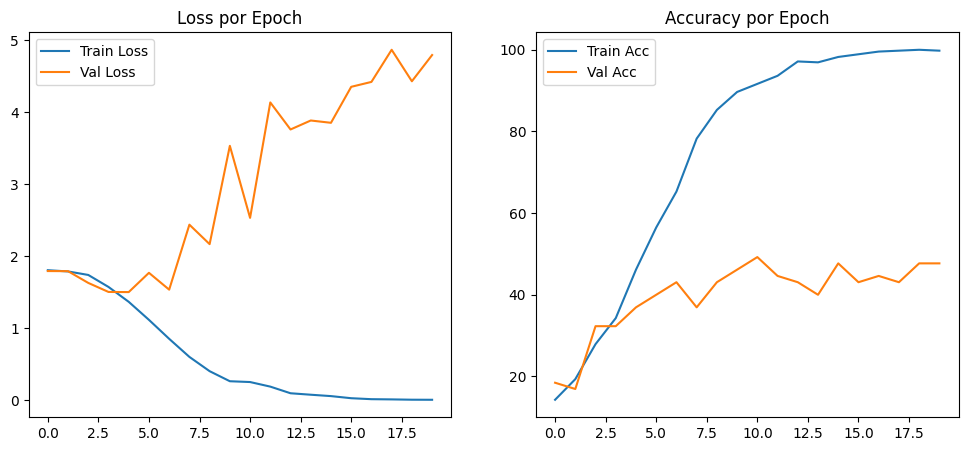

Accuracy del modelo en test: 50.38%


<Figure size 800x600 with 0 Axes>

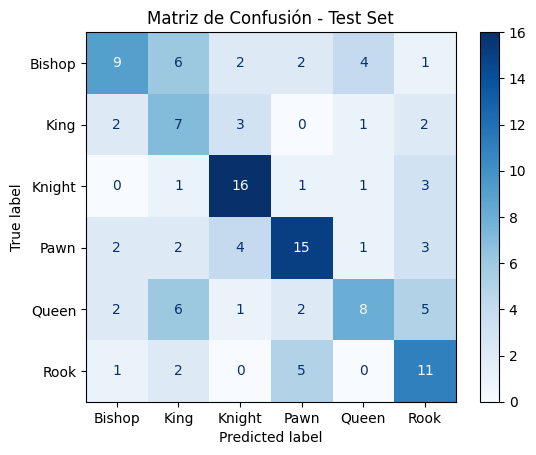

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import os, zipfile
from google.colab import files
import random
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
    random.seed(seed)

seed_everything(42)

# =============================
# SUBIR Y EXTRAER DATASET
# =============================
uploaded = files.upload()
with zipfile.ZipFile("dataset4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset4")

# =============================
# TRANSFORMACIONES DE LAS IMÁGENES
# =============================
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# =============================
# Cargar todo el dataset
# =============================
dataset = datasets.ImageFolder(root="dataset4/dataset4", transform=transform)

# División del dataset
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

# =============================
# DATALOADERS
# =============================
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"Total imágenes: {len(dataset)}")
print(f"Entrenamiento: {len(train_data)}")
print(f"Validación: {len(val_data)}")
print(f"Prueba: {len(test_data)}")
print(f"Clases: {dataset.classes}")

# =============================
# DEFINICIÓN DE LA RED NEURONAL
# =============================
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# =============================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                       factor=0.5, patience=3)

# =============================
# ENTRENAMIENTO
# =============================
epochs = 20
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    # ----- Entrenamiento -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----- Validación -----
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    val_acc_float = float(val_acc)
    scheduler.step(val_acc_float)


# =============================
# GRAFICAS DE PROGRESO
# =============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss por Epoch')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy por Epoch')
plt.show()

# =============================
# EVALUACIÓN FINAL EN TEST
# =============================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy del modelo en test: {100 * correct / total:.2f}%')

# =============================
# MATRIZ DE CONFUSIÓN
# =============================
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()
